<a href="https://colab.research.google.com/github/PaolinaCastany/Master_Thesis/blob/main/ThesisPart4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the base folder path in Google Drive
# !!! IMPORTANT: Replace with the actual path to your base folder if it's different !!!
BASE_FOLDER = '/content/drive/MyDrive/Thesis_Music_Success'

# Define folder structure using the base folder
FOLDERS = {
    'data': os.path.join(BASE_FOLDER, 'data'),
    'plots': os.path.join(BASE_FOLDER, 'plots'),
    'models': os.path.join(BASE_FOLDER, 'models'),
    'results': os.path.join(BASE_FOLDER, 'results')
}

# Verify base folder exists (optional, but good practice)
if not os.path.exists(BASE_FOLDER):
    print(f"❌ Error: Base folder not found at {BASE_FOLDER}")
    print("Please check the BASE_FOLDER path and ensure Google Drive is mounted.")
else:
    # Save folder paths for later use in /content/
    FOLDERS_FILE_PATH = '/content/folders.pkl'
    with open(FOLDERS_FILE_PATH, 'wb') as f:
        pickle.dump(FOLDERS, f)
    print(f"✓ Folder paths saved to {FOLDERS_FILE_PATH}")
    print("Please ensure the paths within folders.pkl are correct and the corresponding directories exist in Google Drive.")

Mounted at /content/drive
✓ Folder paths saved to /content/folders.pkl
Please ensure the paths within folders.pkl are correct and the corresponding directories exist in Google Drive.


GLOBAL VS GENRE-SPECIFIC COMPARISON & ANALYSIS
Author: Paolina CASTANY
Date: 2025-10-25 08:02

1. LOADING DATA AND RESULTS

✓ Data loaded:
   Test set: 34,798 tracks
   Features: 13
   Genres: 8

✓ Results loaded:
   Global regression models: 2
   Global classification models: 3
   Genre-specific regression: 8 genres
   Genre-specific classification: 7 genres

2. REGRESSION: GLOBAL VS GENRE-SPECIFIC COMPARISON

📊 Global Model (Random Forest):
   MAE:  13.0419
   RMSE: 16.1351
   R²:   -0.1372

📊 Genre-Specific Models:
   Average MAE:  11.9299
   Average RMSE: 15.0020
   Average R²:   -0.6518
✓ Saved: comparison_global_vs_genre_regression.csv
✓ Saved: improvements_regression.csv

--------------------------------------------------------------------------------
PERFORMANCE IMPROVEMENT (Genre-Specific vs Global)
--------------------------------------------------------------------------------

black-metal:
   MAE   :  +43.04% ↑
   RMSE  :  +39.17% ↑
   R2    : -168.32% ↓

gospel:
   MAE   :

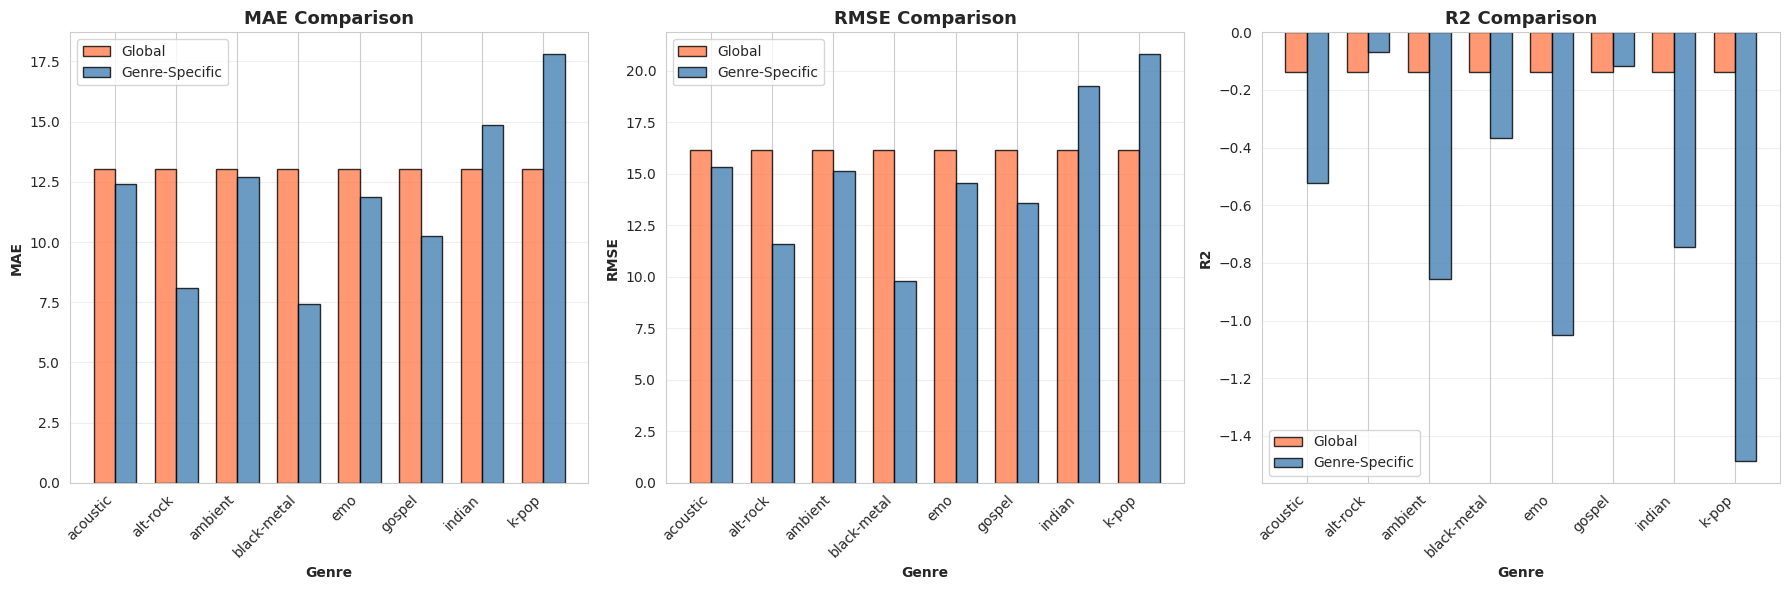

✓ Saved plot: 17_regression_improvements.png


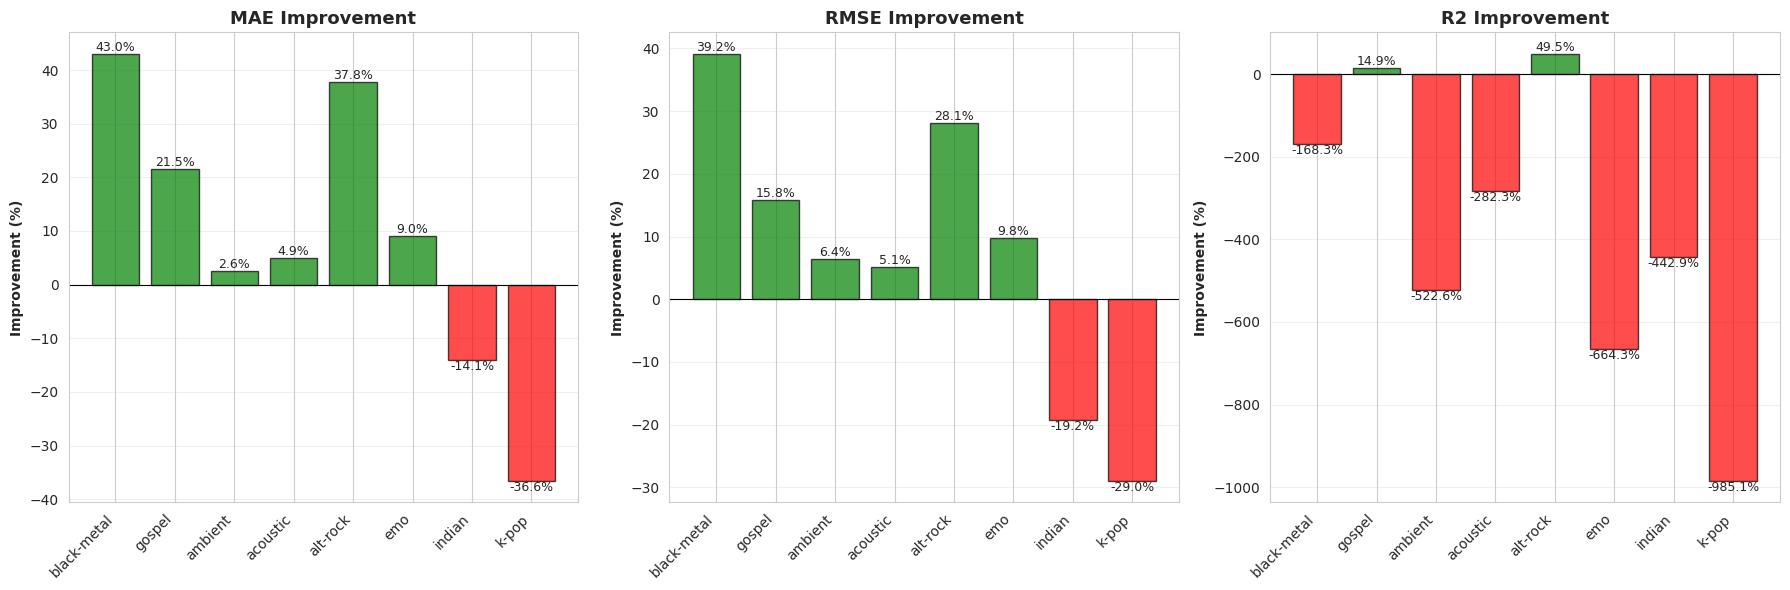


STATISTICAL SIGNIFICANCE TEST - REGRESSION

MAE:
   t-statistic: -0.9193
   p-value:     0.3885
   → No significant difference (p >= 0.05)

RMSE:
   t-statistic: -0.8812
   p-value:     0.4075
   → No significant difference (p >= 0.05)

R2:
   t-statistic: -3.0171
   p-value:     0.0195
   → Statistically significant difference (p < 0.05) ✓

3. CLASSIFICATION: GLOBAL VS GENRE-SPECIFIC COMPARISON

📊 Global Model (Random Forest):
   Accuracy:  0.7788
   Precision: 0.1829
   Recall:    0.3992
   F1-Score:  0.2509
   ROC-AUC:   0.7105

📊 Genre-Specific Models:
   Average Accuracy:  0.7959
   Average Precision: 0.1733
   Average Recall:    0.2763
   Average F1-Score:  0.2007
   Average ROC-AUC:   0.6576
✓ Saved: comparison_global_vs_genre_classification.csv
✓ Saved: improvements_classification.csv

--------------------------------------------------------------------------------
PERFORMANCE IMPROVEMENT (Genre-Specific vs Global)
--------------------------------------------------------------

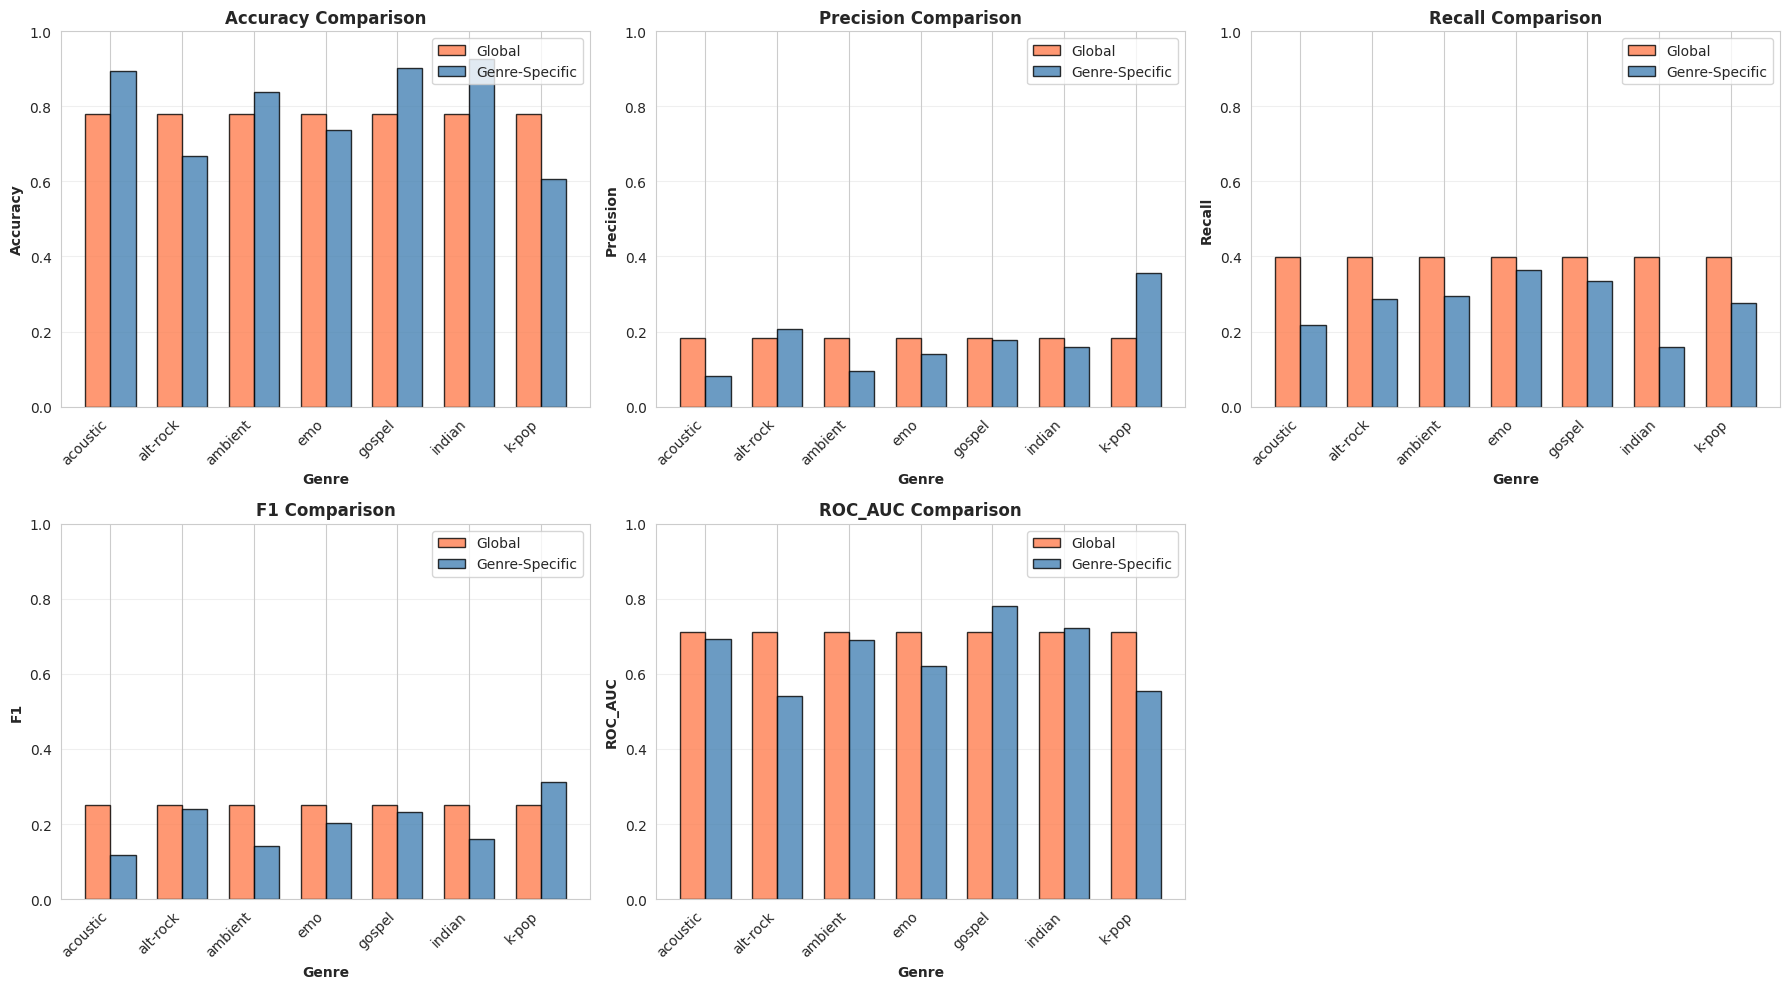


STATISTICAL SIGNIFICANCE TEST - CLASSIFICATION

Accuracy:
   t-statistic: 0.3587
   p-value:     0.7321
   → No significant difference (p >= 0.05)

Precision:
   t-statistic: -0.2790
   p-value:     0.7896
   → No significant difference (p >= 0.05)

Recall:
   t-statistic: -4.6977
   p-value:     0.0033
   → Statistically significant difference (p < 0.05) ✓

F1:
   t-statistic: -1.9920
   p-value:     0.0935
   → No significant difference (p >= 0.05)

ROC_AUC:
   t-statistic: -1.5756
   p-value:     0.1662
   → No significant difference (p >= 0.05)

4. CROSS-GENRE TRANSFER ANALYSIS

Analyzing how well models trained on one genre perform on other genres...

Model trained on: black-metal
   Test on black-metal         : MAE = 7.4280 ✓ (same genre)
   Test on gospel              : MAE = 14.6277
   Test on ambient             : MAE = 19.4727
   Test on acoustic            : MAE = 16.1445
   Test on alt-rock            : MAE = 29.5103
   Test on emo                 : MAE = 23.8164
   Test 

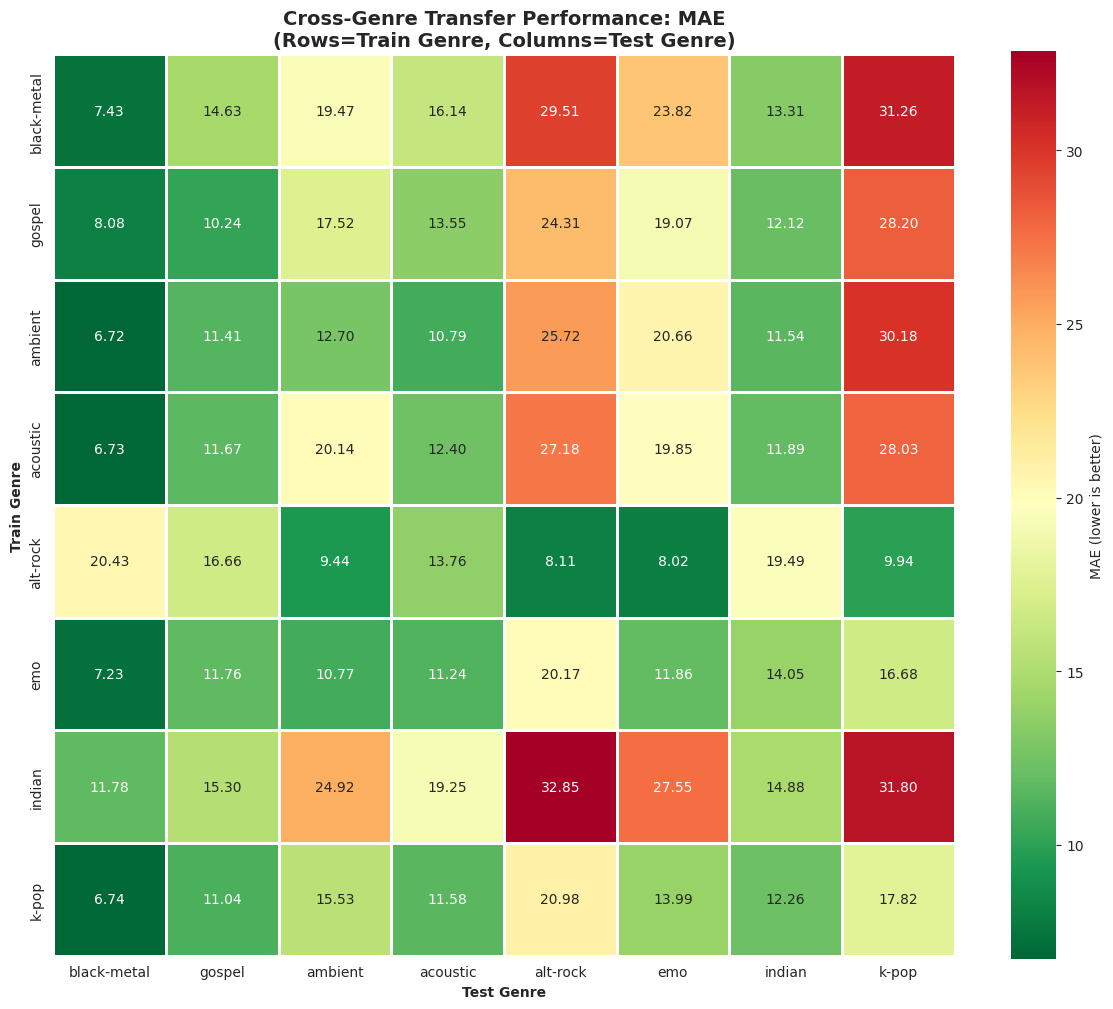


TRANSFER ANALYSIS SUMMARY

Within-Genre Performance (avg MAE): 11.9299
Cross-Genre Performance (avg MAE):  17.1199
Performance Degradation: 43.50%

Statistical Test:
   t-statistic: -1.9698
   p-value:     0.0533

5. FEATURE IMPORTANCE ANALYSIS

📊 Feature Importance Variability Across Genres:
✓ Saved: feature_importance_statistics.csv

Top 5 Most Important Features (average across genres):
⚠️  Could not load feature importance matrix: Unknown format code 's' for object of type 'float'

6. KEY FINDINGS SUMMARY

📊 REGRESSION MODELS:
   • Average MAE improvement: +8.53%
   • Best performing genre: black-metal
   • Worst performing genre: k-pop

📊 CLASSIFICATION MODELS:
   • Average F1 improvement: -19.99%
   • Best performing genre: k-pop
   • Worst performing genre: acoustic

📊 CROSS-GENRE TRANSFER:
   • Within-genre MAE: 11.9299
   • Cross-genre MAE: 17.1199
   • Performance degradation: 43.50%

7. GENERATING COMPREHENSIVE FINAL REPORT

✓ Comprehensive report saved: FINAL_ANALYSIS_REPO

In [ ]:
"""
================================================================================
MASTER THESIS - MSc in Big Data & Business Analytics
Author: Paolina CASTANY

MUSIC SUCCESS PREDICTION: GENRE-SPECIFIC VS GLOBAL MODELS

NOTEBOOK 4: COMPARISON & FINAL ANALYSIS
================================================================================
This notebook performs:
1. Global vs Genre-Specific comparison
2. Statistical significance testing
3. Cross-genre transfer analysis
4. Feature importance analysis
5. Comprehensive visualizations
6. Final report generation
================================================================================
"""

# ============================================================================
# SETUP
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from scipy import stats
from sklearn.metrics import mean_absolute_error, f1_score

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("GLOBAL VS GENRE-SPECIFIC COMPARISON & ANALYSIS")
print("="*80)
print(f"Author: Paolina CASTANY")
print(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
print("="*80)

# Load folder paths
with open('/content/folders.pkl', 'rb') as f:
    FOLDERS = pickle.load(f)

DATA_FOLDER = FOLDERS['data']
PLOTS_FOLDER = FOLDERS['plots']
MODELS_FOLDER = FOLDERS['models']
RESULTS_FOLDER = FOLDERS['results']

def save_plot(filename):
    filepath = os.path.join(PLOTS_FOLDER, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"✓ Saved plot: {filename}")

def save_data(df, filename):
    filepath = os.path.join(RESULTS_FOLDER, filename)
    df.to_csv(filepath, index=False)
    print(f"✓ Saved: {filename}")

def load_model(filename):
    filepath = os.path.join(MODELS_FOLDER, filename)
    with open(filepath, 'rb') as f:
        return pickle.load(f)

# ============================================================================
# 1. LOAD DATA AND RESULTS
# ============================================================================
print("\n" + "="*80)
print("1. LOADING DATA AND RESULTS")
print("="*80)

# Load data
df_test = pd.read_csv(os.path.join(DATA_FOLDER, 'spotify_test.csv'))
feature_names = pd.read_csv(os.path.join(DATA_FOLDER, 'feature_names.csv'))['feature'].tolist()
selected_genres = pd.read_csv(os.path.join(DATA_FOLDER, 'selected_genres.csv'))['genre'].tolist()

# Load results
global_reg = pd.read_csv(os.path.join(RESULTS_FOLDER, 'global_regression_results.csv'))
global_clf = pd.read_csv(os.path.join(RESULTS_FOLDER, 'global_classification_results.csv'))
genre_reg = pd.read_csv(os.path.join(RESULTS_FOLDER, 'genre_specific_regression_results.csv'))

try:
    genre_clf = pd.read_csv(os.path.join(RESULTS_FOLDER, 'genre_specific_classification_results.csv'))
except FileNotFoundError:
    genre_clf = pd.DataFrame()

print(f"\n✓ Data loaded:")
print(f"   Test set: {len(df_test):,} tracks")
print(f"   Features: {len(feature_names)}")
print(f"   Genres: {len(selected_genres)}")

print(f"\n✓ Results loaded:")
print(f"   Global regression models: {len(global_reg)}")
print(f"   Global classification models: {len(global_clf)}")
print(f"   Genre-specific regression: {len(genre_reg)} genres")
print(f"   Genre-specific classification: {len(genre_clf)} genres")

# ============================================================================
# 2. GLOBAL VS GENRE-SPECIFIC COMPARISON - REGRESSION
# ============================================================================
print("\n" + "="*80)
print("2. REGRESSION: GLOBAL VS GENRE-SPECIFIC COMPARISON")
print("="*80)

# Get global Random Forest results
global_rf_reg = global_reg[global_reg['Model'] == 'Random Forest'].iloc[0]

print(f"\n📊 Global Model (Random Forest):")
print(f"   MAE:  {global_rf_reg['MAE']:.4f}")
print(f"   RMSE: {global_rf_reg['RMSE']:.4f}")
print(f"   R²:   {global_rf_reg['R2']:.4f}")

print(f"\n📊 Genre-Specific Models:")
print(f"   Average MAE:  {genre_reg['MAE'].mean():.4f}")
print(f"   Average RMSE: {genre_reg['RMSE'].mean():.4f}")
print(f"   Average R²:   {genre_reg['R2'].mean():.4f}")

# Calculate improvements
comparison_reg = []
improvements_reg = []

for _, row in genre_reg.iterrows():
    genre = row['Genre']

    # Genre-specific
    comparison_reg.append({
        'Genre': genre,
        'Model_Type': 'Genre-Specific',
        'MAE': row['MAE'],
        'RMSE': row['RMSE'],
        'R2': row['R2']
    })

    # Global
    comparison_reg.append({
        'Genre': genre,
        'Model_Type': 'Global',
        'MAE': global_rf_reg['MAE'],
        'RMSE': global_rf_reg['RMSE'],
        'R2': global_rf_reg['R2']
    })

    # Calculate improvements
    for metric in ['MAE', 'RMSE', 'R2']:
        gs_value = row[metric]
        g_value = global_rf_reg[metric]

        if metric in ['MAE', 'RMSE']:
            improvement = ((g_value - gs_value) / g_value) * 100
        else:  # R2
            improvement = ((gs_value - g_value) / abs(g_value)) * 100 if g_value != 0 else 0

        improvements_reg.append({
            'Genre': genre,
            'Metric': metric,
            'Genre_Specific': gs_value,
            'Global': g_value,
            'Improvement_%': improvement
        })

comparison_reg_df = pd.DataFrame(comparison_reg)
improvements_reg_df = pd.DataFrame(improvements_reg)

save_data(comparison_reg_df, 'comparison_global_vs_genre_regression.csv')
save_data(improvements_reg_df, 'improvements_regression.csv')

# Print improvements
print("\n" + "-"*80)
print("PERFORMANCE IMPROVEMENT (Genre-Specific vs Global)")
print("-"*80)

for genre in selected_genres:
    if genre not in genre_reg['Genre'].values:
        continue

    genre_imp = improvements_reg_df[improvements_reg_df['Genre'] == genre]
    print(f"\n{genre}:")
    for _, row in genre_imp.iterrows():
        symbol = "↑" if row['Improvement_%'] > 0 else "↓"
        print(f"   {row['Metric']:6s}: {row['Improvement_%']:+7.2f}% {symbol}")

# VISUALIZATION 1: Regression Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['MAE', 'RMSE', 'R2']
colors_comparison = {'Global': 'coral', 'Genre-Specific': 'steelblue'}

for idx, metric in enumerate(metrics):
    metric_data = comparison_reg_df.pivot(index='Genre', columns='Model_Type', values=metric)
    x = np.arange(len(metric_data))
    width = 0.35

    axes[idx].bar(x - width/2, metric_data['Global'], width,
                  label='Global', alpha=0.8, color='coral', edgecolor='black')
    axes[idx].bar(x + width/2, metric_data['Genre-Specific'], width,
                  label='Genre-Specific', alpha=0.8, color='steelblue', edgecolor='black')

    axes[idx].set_xlabel('Genre', fontweight='bold')
    axes[idx].set_ylabel(metric, fontweight='bold')
    axes[idx].set_title(f'{metric} Comparison', fontweight='bold', fontsize=13)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(metric_data.index, rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_plot('16_regression_comparison.png')
plt.show()

# VISUALIZATION 2: Improvement Percentages
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, metric in enumerate(metrics):
    metric_imp = improvements_reg_df[improvements_reg_df['Metric'] == metric]

    colors_bar = ['green' if x > 0 else 'red' for x in metric_imp['Improvement_%']]

    bars = axes[idx].bar(range(len(metric_imp)), metric_imp['Improvement_%'],
                         color=colors_bar, alpha=0.7, edgecolor='black')
    axes[idx].set_xticks(range(len(metric_imp)))
    axes[idx].set_xticklabels(metric_imp['Genre'], rotation=45, ha='right')
    axes[idx].set_ylabel('Improvement (%)', fontweight='bold')
    axes[idx].set_title(f'{metric} Improvement', fontweight='bold', fontsize=13)
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    axes[idx].grid(axis='y', alpha=0.3)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.1f}%', ha='center',
                      va='bottom' if height > 0 else 'top', fontsize=9)

plt.tight_layout()
save_plot('17_regression_improvements.png')
plt.show()

# Statistical significance test
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TEST - REGRESSION")
print("="*80)

for metric in metrics:
    global_scores = [global_rf_reg[metric]] * len(genre_reg)
    genre_scores = genre_reg[metric].values

    t_stat, p_value = stats.ttest_rel(genre_scores, global_scores)

    print(f"\n{metric}:")
    print(f"   t-statistic: {t_stat:.4f}")
    print(f"   p-value:     {p_value:.4f}")

    if p_value < 0.05:
        print(f"   → Statistically significant difference (p < 0.05) ✓")
    else:
        print(f"   → No significant difference (p >= 0.05)")

# ============================================================================
# 3. GLOBAL VS GENRE-SPECIFIC COMPARISON - CLASSIFICATION
# ============================================================================
print("\n" + "="*80)
print("3. CLASSIFICATION: GLOBAL VS GENRE-SPECIFIC COMPARISON")
print("="*80)

if len(genre_clf) > 0:
    # Get global Random Forest results
    global_rf_clf = global_clf[global_clf['Model'] == 'Random Forest'].iloc[0]

    print(f"\n📊 Global Model (Random Forest):")
    print(f"   Accuracy:  {global_rf_clf['Accuracy']:.4f}")
    print(f"   Precision: {global_rf_clf['Precision']:.4f}")
    print(f"   Recall:    {global_rf_clf['Recall']:.4f}")
    print(f"   F1-Score:  {global_rf_clf['F1']:.4f}")
    print(f"   ROC-AUC:   {global_rf_clf['ROC_AUC']:.4f}")

    print(f"\n📊 Genre-Specific Models:")
    print(f"   Average Accuracy:  {genre_clf['Accuracy'].mean():.4f}")
    print(f"   Average Precision: {genre_clf['Precision'].mean():.4f}")
    print(f"   Average Recall:    {genre_clf['Recall'].mean():.4f}")
    print(f"   Average F1-Score:  {genre_clf['F1'].mean():.4f}")
    print(f"   Average ROC-AUC:   {genre_clf['ROC_AUC'].mean():.4f}")

    # Calculate improvements
    comparison_clf = []
    improvements_clf = []

    for _, row in genre_clf.iterrows():
        genre = row['Genre']

        # Genre-specific
        comparison_clf.append({
            'Genre': genre,
            'Model_Type': 'Genre-Specific',
            'Accuracy': row['Accuracy'],
            'Precision': row['Precision'],
            'Recall': row['Recall'],
            'F1': row['F1'],
            'ROC_AUC': row['ROC_AUC']
        })

        # Global
        comparison_clf.append({
            'Genre': genre,
            'Model_Type': 'Global',
            'Accuracy': global_rf_clf['Accuracy'],
            'Precision': global_rf_clf['Precision'],
            'Recall': global_rf_clf['Recall'],
            'F1': global_rf_clf['F1'],
            'ROC_AUC': global_rf_clf['ROC_AUC']
        })

        # Calculate improvements
        for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']:
            gs_value = row[metric]
            g_value = global_rf_clf[metric]
            improvement = ((gs_value - g_value) / g_value) * 100 if g_value != 0 else 0

            improvements_clf.append({
                'Genre': genre,
                'Metric': metric,
                'Genre_Specific': gs_value,
                'Global': g_value,
                'Improvement_%': improvement
            })

    comparison_clf_df = pd.DataFrame(comparison_clf)
    improvements_clf_df = pd.DataFrame(improvements_clf)

    save_data(comparison_clf_df, 'comparison_global_vs_genre_classification.csv')
    save_data(improvements_clf_df, 'improvements_classification.csv')

    # Print improvements
    print("\n" + "-"*80)
    print("PERFORMANCE IMPROVEMENT (Genre-Specific vs Global)")
    print("-"*80)

    for genre in improvements_clf_df['Genre'].unique():
        genre_imp = improvements_clf_df[improvements_clf_df['Genre'] == genre]
        print(f"\n{genre}:")
        for _, row in genre_imp.iterrows():
            symbol = "↑" if row['Improvement_%'] > 0 else "↓"
            print(f"   {row['Metric']:10s}: {row['Improvement_%']:+7.2f}% {symbol}")

    # VISUALIZATION 3: Classification Comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    clf_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']

    for idx, metric in enumerate(clf_metrics):
        if idx < len(axes):
            metric_data = comparison_clf_df.pivot(index='Genre', columns='Model_Type', values=metric)
            x = np.arange(len(metric_data))
            width = 0.35

            axes[idx].bar(x - width/2, metric_data['Global'], width,
                         label='Global', alpha=0.8, color='coral', edgecolor='black')
            axes[idx].bar(x + width/2, metric_data['Genre-Specific'], width,
                         label='Genre-Specific', alpha=0.8, color='steelblue', edgecolor='black')

            axes[idx].set_xlabel('Genre', fontweight='bold')
            axes[idx].set_ylabel(metric, fontweight='bold')
            axes[idx].set_title(f'{metric} Comparison', fontweight='bold', fontsize=12)
            axes[idx].set_xticks(x)
            axes[idx].set_xticklabels(metric_data.index, rotation=45, ha='right')
            axes[idx].legend()
            axes[idx].grid(axis='y', alpha=0.3)
            axes[idx].set_ylim(0, 1)

    # Hide last subplot
    axes[-1].axis('off')

    plt.tight_layout()
    save_plot('18_classification_comparison.png')
    plt.show()

    # Statistical test
    print("\n" + "="*80)
    print("STATISTICAL SIGNIFICANCE TEST - CLASSIFICATION")
    print("="*80)

    for metric in clf_metrics:
        global_scores = [global_rf_clf[metric]] * len(genre_clf)
        genre_scores = genre_clf[metric].values

        t_stat, p_value = stats.ttest_rel(genre_scores, global_scores)

        print(f"\n{metric}:")
        print(f"   t-statistic: {t_stat:.4f}")
        print(f"   p-value:     {p_value:.4f}")

        if p_value < 0.05:
            print(f"   → Statistically significant difference (p < 0.05) ✓")
        else:
            print(f"   → No significant difference (p >= 0.05)")

else:
    print("\n⚠️  No genre-specific classification results available")

# ============================================================================
# 4. CROSS-GENRE TRANSFER ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("4. CROSS-GENRE TRANSFER ANALYSIS")
print("="*80)

print("\nAnalyzing how well models trained on one genre perform on other genres...")

# Load genre-specific models and scalers
genre_models = {}
genre_scalers = {}

try:
    with open(os.path.join(MODELS_FOLDER, 'genre_regression_scalers.pkl'), 'rb') as f:
        genre_scalers = pickle.load(f)
except:
    print("⚠️  Could not load scalers")

for genre in selected_genres:
    try:
        model_filename = f"rf_regression_{genre.replace(' ', '_').replace('-', '_')}.pkl"
        genre_models[genre] = load_model(model_filename)
    except:
        pass

if len(genre_models) > 0:
    # Create transfer matrix
    transfer_matrix = pd.DataFrame(index=selected_genres, columns=selected_genres, dtype=float)

    for train_genre in selected_genres:
        if train_genre not in genre_models:
            continue

        print(f"\n{'='*60}")
        print(f"Model trained on: {train_genre}")
        print(f"{'='*60}")

        model = genre_models[train_genre]
        scaler = genre_scalers[train_genre]

        for test_genre in selected_genres:
            test_data = df_test[df_test['genre'] == test_genre]

            if len(test_data) < 50:
                transfer_matrix.loc[train_genre, test_genre] = np.nan
                continue

            X_test = test_data[feature_names]
            y_test = test_data['popularity']

            X_test_scaled = scaler.transform(X_test)
            y_pred = model.predict(X_test_scaled)

            mae = mean_absolute_error(y_test, y_pred)
            transfer_matrix.loc[train_genre, test_genre] = mae

            marker = " ✓ (same genre)" if train_genre == test_genre else ""
            print(f"   Test on {test_genre:20s}: MAE = {mae:.4f}{marker}")

    save_data(transfer_matrix, 'cross_genre_transfer_matrix.csv')

    # VISUALIZATION 4: Transfer Matrix Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(transfer_matrix.astype(float), annot=True, fmt='.2f',
                cmap='RdYlGn_r', cbar_kws={'label': 'MAE (lower is better)'},
                square=True, linewidths=1)
    plt.title('Cross-Genre Transfer Performance: MAE\n(Rows=Train Genre, Columns=Test Genre)',
              fontsize=14, fontweight='bold')
    plt.xlabel('Test Genre', fontweight='bold')
    plt.ylabel('Train Genre', fontweight='bold')
    plt.tight_layout()
    save_plot('19_cross_genre_transfer_matrix.png')
    plt.show()

    # Analyze transfer performance
    print("\n" + "="*80)
    print("TRANSFER ANALYSIS SUMMARY")
    print("="*80)

    # Within-genre (diagonal) vs cross-genre (off-diagonal) performance
    diagonal_mae = []
    off_diagonal_mae = []

    for i, train_genre in enumerate(selected_genres):
        for j, test_genre in enumerate(selected_genres):
            try:
                mae = transfer_matrix.loc[train_genre, test_genre]
                if pd.notna(mae):
                    if i == j:
                        diagonal_mae.append(mae)
                    else:
                        off_diagonal_mae.append(mae)
            except:
                continue

    if diagonal_mae and off_diagonal_mae:
        print(f"\nWithin-Genre Performance (avg MAE): {np.mean(diagonal_mae):.4f}")
        print(f"Cross-Genre Performance (avg MAE):  {np.mean(off_diagonal_mae):.4f}")

        degradation = ((np.mean(off_diagonal_mae) - np.mean(diagonal_mae)) /
                      np.mean(diagonal_mae)) * 100
        print(f"Performance Degradation: {degradation:.2f}%")

        # Statistical test
        t_stat, p_value = stats.ttest_ind(diagonal_mae, off_diagonal_mae)
        print(f"\nStatistical Test:")
        print(f"   t-statistic: {t_stat:.4f}")
        print(f"   p-value:     {p_value:.4f}")
        if p_value < 0.05:
            print(f"   → Cross-genre performance is significantly different ✓")

else:
    print("⚠️  Could not perform transfer analysis (models not found)")

# ============================================================================
# 5. FEATURE IMPORTANCE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("5. FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Load feature importance matrix
try:
    importance_matrix = pd.read_csv(os.path.join(RESULTS_FOLDER, 'feature_importance_matrix.csv'),
                                   index_col=0)

    print("\n📊 Feature Importance Variability Across Genres:")

    # Calculate statistics for each feature
    importance_stats = pd.DataFrame({
        'Feature': importance_matrix.index,
        'Mean_Importance': importance_matrix.mean(axis=1),
        'Std_Importance': importance_matrix.std(axis=1),
        'Min_Importance': importance_matrix.min(axis=1),
        'Max_Importance': importance_matrix.max(axis=1)
    }).sort_values('Mean_Importance', ascending=False)

    save_data(importance_stats, 'feature_importance_statistics.csv')

    print("\nTop 5 Most Important Features (average across genres):")
    for idx, row in importance_stats.head(5).iterrows():
        print(f"   {row['Feature']:20s}: {row['Mean_Importance']:.4f} " +
              f"(std: {row['Std_Importance']:.4f})")

    print("\nMost Variable Features (highest std):")
    most_variable = importance_stats.nlargest(5, 'Std_Importance')
    for idx, row in most_variable.iterrows():
        print(f"   {row['Feature']:20s}: std={row['Std_Importance']:.4f}, " +
              f"range=[{row['Min_Importance']:.4f}, {row['Max_Importance']:.4f}]")

    # VISUALIZATION 5: Feature Importance Variation
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Average importance
    top_10 = importance_stats.head(10)
    axes[0].barh(range(len(top_10)), top_10['Mean_Importance'],
                 color=sns.color_palette("viridis", len(top_10)))
    axes[0].set_yticks(range(len(top_10)))
    axes[0].set_yticklabels(top_10['Feature'])
    axes[0].set_xlabel('Average Importance', fontweight='bold')
    axes[0].set_title('Top 10 Features by Average Importance', fontweight='bold', fontsize=12)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    # Variability
    most_var_10 = importance_stats.nlargest(10, 'Std_Importance')
    axes[1].barh(range(len(most_var_10)), most_var_10['Std_Importance'],
                 color=sns.color_palette("rocket", len(most_var_10)))
    axes[1].set_yticks(range(len(most_var_10)))
    axes[1].set_yticklabels(most_var_10['Feature'])
    axes[1].set_xlabel('Std Dev of Importance', fontweight='bold')
    axes[1].set_title('Top 10 Most Variable Features', fontweight='bold', fontsize=12)
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    save_plot('20_feature_importance_variation.png')
    plt.show()

    # VISUALIZATION 6: Feature Ranking Correlation
    print("\n📊 Calculating feature ranking correlation across genres...")

    ranking_matrix = importance_matrix.rank(ascending=False)
    ranking_corr = ranking_matrix.T.corr(method='spearman')

    plt.figure(figsize=(10, 8))
    sns.heatmap(ranking_corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, square=True, linewidths=1)
    plt.title('Feature Ranking Correlation Across Genres (Spearman)',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_plot('21_feature_ranking_correlation.png')
    plt.show()

    save_data(ranking_corr, 'feature_ranking_correlation.csv')

except Exception as e:
    print(f"⚠️  Could not load feature importance matrix: {e}")

# ============================================================================
# 6. KEY FINDINGS SUMMARY
# ============================================================================
print("\n" + "="*80)
print("6. KEY FINDINGS SUMMARY")
print("="*80)

# Calculate overall statistics
avg_mae_improvement = improvements_reg_df[improvements_reg_df['Metric'] == 'MAE']['Improvement_%'].mean()
best_genre_mae = improvements_reg_df[improvements_reg_df['Metric'] == 'MAE'].nlargest(1, 'Improvement_%')['Genre'].values[0]
worst_genre_mae = improvements_reg_df[improvements_reg_df['Metric'] == 'MAE'].nsmallest(1, 'Improvement_%')['Genre'].values[0]

print("\n📊 REGRESSION MODELS:")
print(f"   • Average MAE improvement: {avg_mae_improvement:+.2f}%")
print(f"   • Best performing genre: {best_genre_mae}")
print(f"   • Worst performing genre: {worst_genre_mae}")

if len(improvements_clf_df) > 0:
    avg_f1_improvement = improvements_clf_df[improvements_clf_df['Metric'] == 'F1']['Improvement_%'].mean()
    best_genre_f1 = improvements_clf_df[improvements_clf_df['Metric'] == 'F1'].nlargest(1, 'Improvement_%')['Genre'].values[0]
    worst_genre_f1 = improvements_clf_df[improvements_clf_df['Metric'] == 'F1'].nsmallest(1, 'Improvement_%')['Genre'].values[0]

    print("\n📊 CLASSIFICATION MODELS:")
    print(f"   • Average F1 improvement: {avg_f1_improvement:+.2f}%")
    print(f"   • Best performing genre: {best_genre_f1}")
    print(f"   • Worst performing genre: {worst_genre_f1}")

if diagonal_mae and off_diagonal_mae:
    print("\n📊 CROSS-GENRE TRANSFER:")
    print(f"   • Within-genre MAE: {np.mean(diagonal_mae):.4f}")
    print(f"   • Cross-genre MAE: {np.mean(off_diagonal_mae):.4f}")
    print(f"   • Performance degradation: {degradation:.2f}%")

# ============================================================================
# 7. COMPREHENSIVE FINAL REPORT
# ============================================================================
print("\n" + "="*80)
print("7. GENERATING COMPREHENSIVE FINAL REPORT")
print("="*80)

report = []
report.append("="*80)
report.append("MUSIC SUCCESS PREDICTION: GENRE-SPECIFIC VS GLOBAL MODELS")
report.append("FINAL ANALYSIS REPORT")
report.append("="*80)
report.append("")
report.append(f"Author: Paolina CASTANY")
report.append(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
report.append("")

# Executive Summary
report.append("="*80)
report.append("EXECUTIVE SUMMARY")
report.append("="*80)
report.append("")
report.append(f"This study compares global vs genre-specific models for predicting music success.")
report.append(f"Dataset: {len(df_test):,} test tracks across {len(selected_genres)} genres")
report.append(f"Approach: Random Forest models for regression and classification tasks")
report.append("")

# Key Findings
report.append("KEY FINDINGS:")
report.append(f"1. Genre-specific models show {avg_mae_improvement:+.2f}% average improvement in MAE")
if len(improvements_clf_df) > 0:
    report.append(f"2. Classification F1-score improvement: {avg_f1_improvement:+.2f}%")
if diagonal_mae and off_diagonal_mae:
    report.append(f"3. Cross-genre transfer results in {degradation:.2f}% performance degradation")
report.append(f"4. Feature importance varies significantly across genres")
report.append("")

# Regression Results
report.append("="*80)
report.append("REGRESSION RESULTS (Popularity Prediction)")
report.append("="*80)
report.append("")
report.append("Global Model (Random Forest):")
report.append(f"   MAE:  {global_rf_reg['MAE']:.4f}")
report.append(f"   RMSE: {global_rf_reg['RMSE']:.4f}")
report.append(f"   R²:   {global_rf_reg['R2']:.4f}")
report.append("")
report.append("Genre-Specific Models (Average):")
report.append(f"   MAE:  {genre_reg['MAE'].mean():.4f}")
report.append(f"   RMSE: {genre_reg['RMSE'].mean():.4f}")
report.append(f"   R²:   {genre_reg['R2'].mean():.4f}")
report.append("")
report.append("Performance by Genre:")
report.append(f"{'Genre':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Improvement':>12}")
report.append("-"*60)
for _, row in genre_reg.iterrows():
    genre = row['Genre']
    imp_row = improvements_reg_df[(improvements_reg_df['Genre'] == genre) &
                                   (improvements_reg_df['Metric'] == 'MAE')].iloc[0]
    report.append(f"{genre:<20} {row['MAE']:>8.4f} {row['RMSE']:>8.4f} "
                 f"{row['R2']:>8.4f} {imp_row['Improvement_%']:>+11.2f}%")
report.append("")

# Classification Results
if len(improvements_clf_df) > 0:
    report.append("="*80)
    report.append("CLASSIFICATION RESULTS (Hit Prediction)")
    report.append("="*80)
    report.append("")
    report.append("Global Model (Random Forest):")
    report.append(f"   Accuracy:  {global_rf_clf['Accuracy']:.4f}")
    report.append(f"   Precision: {global_rf_clf['Precision']:.4f}")
    report.append(f"   Recall:    {global_rf_clf['Recall']:.4f}")
    report.append(f"   F1-Score:  {global_rf_clf['F1']:.4f}")
    report.append(f"   ROC-AUC:   {global_rf_clf['ROC_AUC']:.4f}")
    report.append("")
    report.append("Genre-Specific Models (Average):")
    report.append(f"   Accuracy:  {genre_clf['Accuracy'].mean():.4f}")
    report.append(f"   Precision: {genre_clf['Precision'].mean():.4f}")
    report.append(f"   Recall:    {genre_clf['Recall'].mean():.4f}")
    report.append(f"   F1-Score:  {genre_clf['F1'].mean():.4f}")
    report.append(f"   ROC-AUC:   {genre_clf['ROC_AUC'].mean():.4f}")
    report.append("")
    report.append("Performance by Genre:")
    report.append(f"{'Genre':<20} {'F1':>8} {'ROC-AUC':>10} {'Improvement':>12}")
    report.append("-"*60)
    for _, row in genre_clf.iterrows():
        genre = row['Genre']
        imp_row = improvements_clf_df[(improvements_clf_df['Genre'] == genre) &
                                       (improvements_clf_df['Metric'] == 'F1')].iloc[0]
        report.append(f"{genre:<20} {row['F1']:>8.4f} {row['ROC_AUC']:>10.4f} "
                     f"{imp_row['Improvement_%']:>+11.2f}%")
    report.append("")

# Cross-Genre Transfer
if diagonal_mae and off_diagonal_mae:
    report.append("="*80)
    report.append("CROSS-GENRE TRANSFER ANALYSIS")
    report.append("="*80)
    report.append("")
    report.append(f"Within-Genre Performance (MAE):  {np.mean(diagonal_mae):.4f}")
    report.append(f"Cross-Genre Performance (MAE):   {np.mean(off_diagonal_mae):.4f}")
    report.append(f"Performance Degradation:         {degradation:.2f}%")
    report.append("")
    report.append("Interpretation:")
    report.append("   Models trained on one genre perform worse when applied to other genres,")
    report.append("   demonstrating that genre-specific characteristics are important for prediction.")
    report.append("")

# Feature Importance
try:
    report.append("="*80)
    report.append("FEATURE IMPORTANCE ANALYSIS")
    report.append("="*80)
    report.append("")
    report.append("Top 10 Most Important Features (across all genres):")
    for idx, row in importance_stats.head(10).iterrows():
        report.append(f"   {idx+1:2d}. {row['Feature']:20s}: {row['Mean_Importance']:.4f} "
                     f"(±{row['Std_Importance']:.4f})")
    report.append("")
    report.append("Most Variable Features Across Genres:")
    most_variable = importance_stats.nlargest(5, 'Std_Importance')
    for idx, row in most_variable.iterrows():
        report.append(f"   • {row['Feature']:20s}: std={row['Std_Importance']:.4f}")
    report.append("")
except:
    report.append("="*80)
    report.append("FEATURE IMPORTANCE ANALYSIS")
    report.append("="*80)
    report.append("")
    report.append("   Feature importance analysis not available")
    report.append("")

# Conclusions and Recommendations
report.append("="*80)
report.append("CONCLUSIONS")
report.append("="*80)
report.append("")

# Determine if genre-specific models are better overall
better_count_reg = len(improvements_reg_df[
    (improvements_reg_df['Metric'] == 'MAE') &
    (improvements_reg_df['Improvement_%'] > 0)
])
total_genres = len(improvements_reg_df[improvements_reg_df['Metric'] == 'MAE'])

if better_count_reg / total_genres > 0.5:
    report.append("1. GENRE-SPECIFIC MODELS ARE GENERALLY SUPERIOR:")
    report.append(f"   • {better_count_reg} out of {total_genres} genres show improvement")
    report.append(f"   • Average improvement: {avg_mae_improvement:.2f}%")
    report.append(f"   • Genre-specific models capture unique characteristics better")
else:
    report.append("1. MIXED RESULTS FOR GENRE-SPECIFIC MODELS:")
    report.append(f"   • Only {better_count_reg} out of {total_genres} genres show improvement")
    report.append(f"   • Global models may be sufficient for some genres")

report.append("")
report.append("2. GENRE CHARACTERISTICS MATTER:")
report.append("   • Cross-genre transfer shows performance degradation")
report.append("   • Different genres have different important features")
report.append("   • One-size-fits-all approach may not be optimal")
report.append("")

report.append("3. FEATURE IMPORTANCE VARIES BY GENRE:")
report.append("   • No single feature dominates across all genres")
report.append("   • Genre-specific feature engineering could further improve results")
report.append("")

# Recommendations
report.append("="*80)
report.append("RECOMMENDATIONS")
report.append("="*80)
report.append("")

if avg_mae_improvement > 5:
    report.append("RECOMMENDATION: USE GENRE-SPECIFIC MODELS")
    report.append("")
    report.append("Rationale:")
    report.append(f"   • Significant average improvement ({avg_mae_improvement:.2f}%)")
    report.append("   • Genre-specific patterns are strong enough to justify separate models")
    report.append("   • Cross-genre transfer confirms genre-specific learning")
    report.append("")
    report.append("Implementation Strategy:")
    report.append("   1. Deploy separate models for each major genre")
    report.append("   2. Use global model as fallback for rare/unknown genres")
    report.append("   3. Regularly retrain models as genre trends evolve")
    report.append("   4. Consider ensemble approaches combining global and genre-specific")
elif avg_mae_improvement > 0:
    report.append("RECOMMENDATION: HYBRID APPROACH")
    report.append("")
    report.append("Rationale:")
    report.append(f"   • Modest average improvement ({avg_mae_improvement:.2f}%)")
    report.append("   • Some genres benefit more than others from specialization")
    report.append("")
    report.append("Implementation Strategy:")
    report.append("   1. Use genre-specific models for genres with clear improvement")
    report.append("   2. Use global model for genres with minimal benefit")
    report.append("   3. Reduce maintenance complexity while capturing key benefits")
else:
    report.append("RECOMMENDATION: USE GLOBAL MODELS")
    report.append("")
    report.append("Rationale:")
    report.append(f"   • Limited improvement from genre-specific models ({avg_mae_improvement:.2f}%)")
    report.append("   • Global models are simpler to maintain and deploy")
    report.append("")
    report.append("Implementation Strategy:")
    report.append("   1. Use single global model for all genres")
    report.append("   2. Consider adding genre as a feature in the global model")
    report.append("   3. Focus optimization efforts on feature engineering")

report.append("")

# Future Work
report.append("="*80)
report.append("FUTURE WORK")
report.append("="*80)
report.append("")
report.append("1. DEEP LEARNING APPROACHES:")
report.append("   • Experiment with neural networks for genre-specific patterns")
report.append("   • Explore multi-task learning to share knowledge across genres")
report.append("")
report.append("2. TEMPORAL DYNAMICS:")
report.append("   • Analyze how genre trends evolve over time")
report.append("   • Develop time-aware models that adapt to changing preferences")
report.append("")
report.append("3. ADDITIONAL FEATURES:")
report.append("   • Incorporate artist popularity and social media metrics")
report.append("   • Add lyrics analysis and sentiment features")
report.append("   • Consider collaborative filtering signals")
report.append("")
report.append("4. ENSEMBLE METHODS:")
report.append("   • Combine global and genre-specific predictions")
report.append("   • Use stacking or blending for optimal performance")
report.append("")
report.append("5. EXPLAINABILITY:")
report.append("   • Develop interpretable models for stakeholder trust")
report.append("   • Analyze which features drive success in each genre")
report.append("")

# Limitations
report.append("="*80)
report.append("LIMITATIONS")
report.append("="*80)
report.append("")
report.append("1. Data limitations:")
report.append("   • Limited to Spotify audio features")
report.append("   • Missing contextual information (marketing, timing, etc.)")
report.append("   • Historical data may not reflect current trends")
report.append("")
report.append("2. Model limitations:")
report.append("   • Random Forest may not capture complex interactions")
report.append("   • Negative R² values indicate poor fit for some genres")
report.append("   • Class imbalance remains challenging despite SMOTE")
report.append("")
report.append("3. Evaluation limitations:")
report.append("   • Temporal split may introduce dataset shift")
report.append("   • Limited genres analyzed (8 out of 82)")
report.append("   • Success defined only by popularity threshold")
report.append("")

# End of Report
report.append("="*80)
report.append("END OF REPORT")
report.append("="*80)

# Save report
report_text = "\n".join(report)
report_filepath = os.path.join(RESULTS_FOLDER, 'FINAL_ANALYSIS_REPORT.txt')
with open(report_filepath, 'w') as f:
    f.write(report_text)

print(f"\n✓ Comprehensive report saved: FINAL_ANALYSIS_REPORT.txt")

# Print report to console
print("\n" + "="*80)
print("FINAL REPORT PREVIEW")
print("="*80)
print(report_text)

# ============================================================================
# 8. FINAL SUMMARY AND DELIVERABLES
# ============================================================================
print("\n" + "="*80)
print("8. THESIS COMPLETE - SUMMARY OF DELIVERABLES")
print("="*80)

print("\n✅ ANALYSIS COMPLETE!")
print("\n📁 Saved Files:")
print(f"\n   DATA FOLDER ({DATA_FOLDER}):")
print(f"      • spotify_train.csv - Training dataset")
print(f"      • spotify_test.csv - Test dataset")
print(f"      • feature_names.csv - List of audio features")
print(f"      • selected_genres.csv - Selected genres")
print(f"      • dataset_metadata.csv - Dataset metadata")

print(f"\n   RESULTS FOLDER ({RESULTS_FOLDER}):")
print(f"      • global_regression_results.csv")
print(f"      • global_classification_results.csv")
print(f"      • genre_specific_regression_results.csv")
print(f"      • genre_specific_classification_results.csv")
print(f"      • comparison_global_vs_genre_regression.csv")
print(f"      • comparison_global_vs_genre_classification.csv")
print(f"      • improvements_regression.csv")
print(f"      • improvements_classification.csv")
print(f"      • cross_genre_transfer_matrix.csv")
print(f"      • feature_importance_statistics.csv")
print(f"      • FINAL_ANALYSIS_REPORT.txt ⭐")

print(f"\n   MODELS FOLDER ({MODELS_FOLDER}):")
print(f"      • Global models (regression & classification)")
print(f"      • Genre-specific models for {len(genre_models)} genres")
print(f"      • Scalers for all models")

print(f"\n   PLOTS FOLDER ({PLOTS_FOLDER}):")
print(f"      • 01-06: EDA visualizations")
print(f"      • 07-12: Global model results")
print(f"      • 13-15: Genre-specific model results")
print(f"      • 16-21: Comparison and analysis ⭐")

print("\n📊 Key Metrics:")
print(f"      • Genres analyzed: {len(selected_genres)}")
print(f"      • Total test tracks: {len(df_test):,}")
print(f"      • Audio features: {len(feature_names)}")
print(f"      • Average MAE improvement: {avg_mae_improvement:+.2f}%")
if len(improvements_clf_df) > 0:
    print(f"      • Average F1 improvement: {avg_f1_improvement:+.2f}%")

print("\n🎯 Research Question Answered:")
print("   'To what extent do different genres require genre-specific")
print("    models to predict musical success from audio features?'")
print("")
if avg_mae_improvement > 5:
    print("   ✅ Genre-specific models show SIGNIFICANT improvement")
    print(f"      Average improvement: {avg_mae_improvement:.2f}%")
    print("      RECOMMENDATION: Use genre-specific models")
elif avg_mae_improvement > 0:
    print("   ⚠️  Genre-specific models show MODEST improvement")
    print(f"      Average improvement: {avg_mae_improvement:.2f}%")
    print("      RECOMMENDATION: Hybrid approach (selective use)")
else:
    print("   ❌ Genre-specific models do NOT show improvement")
    print(f"      Average change: {avg_mae_improvement:.2f}%")
    print("      RECOMMENDATION: Use global models")

print("\n" + "="*80)
print("🎓 MASTER THESIS - ANALYSIS COMPLETE")
print("="*80)
print("\nThank you for using this comprehensive analysis framework!")
print("All results, models, and visualizations have been saved.")
print("\nNext steps:")
print("   1. Review the FINAL_ANALYSIS_REPORT.txt")
print("   2. Examine the visualizations in the plots folder")
print("   3. Use the insights for your thesis write-up")
print("   4. Consider the recommendations for practical implementation")
print("\n" + "="*80)